# Thực hành 5: Bài toán thỏa mãn ràng buộc

In [1]:
%load_ext autoreload
%autoreload 2


## 1. Bài toán sinh tổ hợp

Cho tập hợp A có n phần tử đôi một khác nhau. Mỗi phần tử là một ký tự từ A → Z. Hãy liệt kê các tập hợp của tập
hợp có N phần tử lấy từ K phần tử.

In [1]:
%%writefile tohop.inp
3 2
F
A
B

Overwriting tohop.inp


### Đọc dữ liệu

In [2]:
from tohop import *

n, k, comb = readFile(filepath="tohop.inp")
print(f'n = {n}\nk = {k}\ncomb = {comb}')


Data file read successfully!
n = 3
k = 2
comb = ['F', 'A', 'B']


### Cài đăt backtracking

In [3]:
backtracking(n=n, k=k, result=[], build=[], combination=comb, start=0, debug=False)

### Sinh tổ hợp

In [ ]:
result = combine(n=n, k=k, combination = comb, debug=False)
print_result(result)

3
FA
FB
AB


### Kiểm tra thuật toán

In [6]:
import math

combination = ['A','B','C','D','E','F','G','H','I','J','K','L','M','N']
tests = [
    (5, 3),
    (6, 2),
    (7, 3),
    (8, 4),
    (10, 3),
    (10, 5),
    (14, 5),
]

for n, k in tests:
    agg = combination[:n]
    expected = math.comb(n, k)
    result = combine(n=n, k=k, combination=agg)

    ok = (len(result) == expected)
    print(f'n={n:2} k={k:2}  backtracking={len(result):5}  nCk={expected:5}  {"PASS" if ok else "FAIL"}')

n= 5 k= 3  backtracking=   10  nCk=   10  PASS
n= 6 k= 2  backtracking=   15  nCk=   15  PASS
n= 7 k= 3  backtracking=   35  nCk=   35  PASS
n= 8 k= 4  backtracking=   70  nCk=   70  PASS
n=10 k= 3  backtracking=  120  nCk=  120  PASS
n=10 k= 5  backtracking=  252  nCk=  252  PASS
n=14 k= 5  backtracking= 2002  nCk= 2002  PASS


## 2. Xếp hậu (đặt N quân hậu)

Xét bàn cờ tổng quát kích thước NxN. Một quân hậu trên bàn cờ có thể ăn được các quân khác nằm tại các ô cùng
hàng, cùng cột hoặc cùng đường chéo. Hãy liệt kê tất cả các cách xếp N quân hậu trên bàn cờ sao cho không có quân
hậu nào ăn nhau. (3<=N<=100).(Làm hai cách: đệ quy quay lui và tham lam từng phần)

In [1]:
%%writefile xephau.inp
5

Overwriting xephau.inp


### Đọc dữ liệu

In [2]:
from xephau import *

n = readFile("xephau.inp")
print(f'n = {n}')

Đọc dữ liệu thành công!
n = 5


### Cách 1: Backtracking

```
backtracking(n, col)
    nếu col == N return SUCCESS //đặt đủ hậu
    else
        Với mỗi dòng trong cột col:
            Thử thêm hậu vào bàn cờ
            backtracking(n, col + 1) // sang cột tiếp theo
            Lấy hậu ra sau khi thử
        
xephau(n)
    Ban đồ bàn cờ rỗng
    backtracking(n, col = 0)
```



#### Kiểm tra xung đột

In [3]:
"""
                                            + + Q +       
pos = [1,3,0,2] tương đương với bàn cờ :    Q + + +
                                            + + + Q
                                            + Q + +

check_valid(0, 1, pos = [1,3,0,2]) : kiểm tra ô [0,1] có xung đột với các hậu khác không
trả về True (hợp lệ) và False (có xung đột)
"""
valid = check_valid(0, 1, pos = [1,3,0,2])  
print(valid)

False


In [4]:
result = xephau_bactracking(n)
print(f'Tất cả các nghiệm: ({len(result)} nghiệm)')
print(result)

Tất cả các nghiệm: (10 nghiệm)
[[0, 2, 4, 1, 3], [0, 3, 1, 4, 2], [1, 3, 0, 2, 4], [1, 4, 2, 0, 3], [2, 0, 3, 1, 4], [2, 4, 1, 3, 0], [3, 0, 2, 4, 1], [3, 1, 4, 2, 0], [4, 1, 3, 0, 2], [4, 2, 0, 3, 1]]


### Kết quả

In [5]:
if len(result) > 0: 
    pos_v = result[0]
    print(1)
    print_board(board(n,pos_v))
    pass
else: print(0)


1
1 0 0 0 0 
0 0 0 1 0 
0 1 0 0 0 
0 0 0 0 1 
0 0 1 0 0 



#### Vẽ cây backtracking với n = {3, 4}

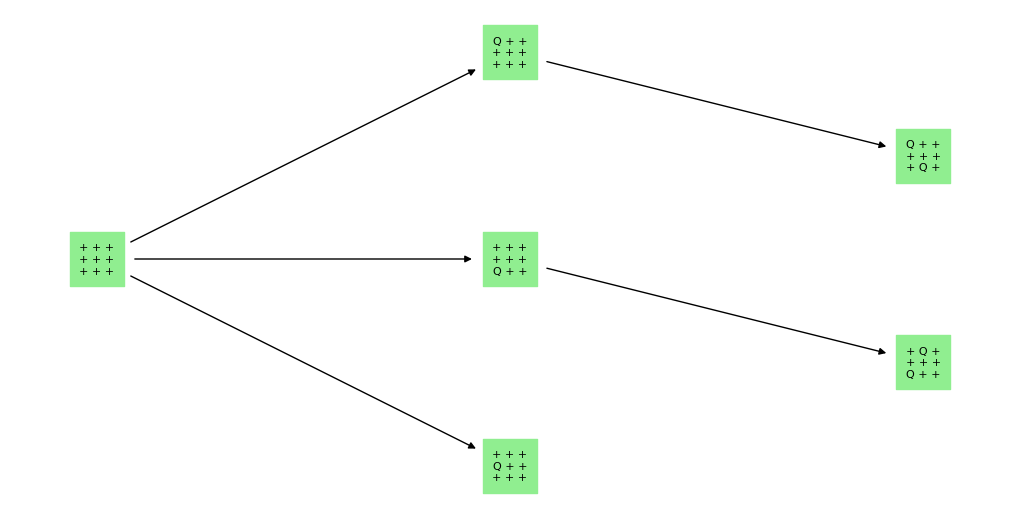

Vô nghiệm


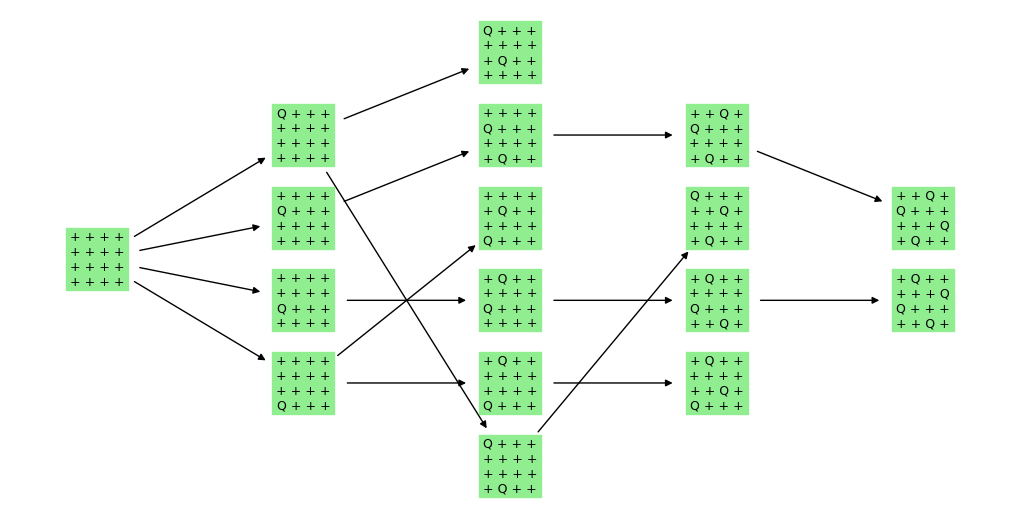

[[1, 3, 0, 2], [2, 0, 3, 1]]

In [6]:
xephau_bactracking(n = 3, draw_tree = True, queens=True)
xephau_bactracking(n = 4, draw_tree = True, queens=True)

### Cách 2: Thuật toán Tham lam (Min-Conflicts)

```
Khởi tạo ngẫu nhiên trạng thái ban đầu pos
Tính h(state)
While h(state) ≠ 0 DO
    Chọn ngẫu nhiên một cột i sao cho
    quân hậu tại đó đang gây xung đột
    best_row ← hàng hiện tại
    min_conflict ← +∞
    for mỗi hàng j từ 0 đến n-1 DO //tìm ô gây xung đột tối thiểu
        Tạm đặt pos[i] = j
        Tính hệ số xung đột mới
        Nếu số xung đột < min_conflict:
            min_conflict ← số xung đột
            best_row ← r

    pos[i] ← best_row
END WHILE

```

#### Tính tổng số cặp đang xung đột (heuristic chính)


In [7]:
a_pos = [0,0,0,0,0,0,0,0,0] # trên cùng cột nến số cặp xung đột là nCr(9,2) = 36 cặp tấn công nhau 
count_conflicting_pairs(a_pos)

36

#### Tính số xung đột tại một ô với các cột khác

In [8]:
"""
X . . + . . + . .       
Q + . + . + . . .   
Q . + + + . . . .    
Q + + O + + + + +    
Q . + + + . . . .    
Q + . + . + . . .    
X . . + . . + . .    
Q . . + . . . + .   
"""
count_conflicts_of_cell(3,3,a_pos) # Ô (3,3) xung đột với hậu ô (0,0) và (6,0) không tính hàng đang xét

2

#### Cài đặt tham lam

In [168]:
pos = xephau_thamlam(n, step=True)

Giả sử ban đầu ta đặt các hậu ở hàng 0
pos = [0, 0, 0, 0, 0, 0, 0, 0, 0]
  h = 36
[[1 1 1 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]]

  h = 28
[[1 1 1 1 0 1 1 1 1]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0]]

  h = 21
[[1 1 1 1 0 0 1 1 1]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0]]

  h = 16
[[1 1 1 0 0 0 1 1 1]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0]
 [0 0 0 1 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0]]

  h = 11
[[0 1 1 0 0 0 1 1 1]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0

#### Kết quả

In [169]:
if pos is None:
    print(0)
else:
    print(1)
    print(board_to_string(board(n, pos)))

1
1 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 1 0
0 0 0 0 1 0 0 0 0
0 0 1 0 0 0 0 0 0
0 0 0 0 0 1 0 0 0
0 0 0 0 0 0 0 0 1
0 1 0 0 0 0 0 0 0
0 0 0 1 0 0 0 0 0
0 0 0 0 0 0 1 0 0


## 3. Mã đi tuần (đường đóng)

*Xem thêm: https://en.wikipedia.org/wiki/Knight%27s_tour*

Trong bàn cờ tổng quát kích thước NxN, con mã được đặt tại vị trí x0, y0. Hãy chỉ ra lộ trình con mã đi qua tất cả
các ô mà mỗi ô chỉ đi qua đúng một lần và trở lại vị trí ban đầu. (2<=N<=10).


In [170]:
%%writefile madituan.inp
6 1 6

Overwriting madituan.inp


### Đọc dữ liệu

In [171]:
from madituan import *
n, x0, y0 = readFile("madituan.inp")
print(f'n = {n}, x0 = {x0}, y0 = {y0}')

Đọc dữ liệu thành công!
n = 6, x0 = 1, y0 = 6


### Cách 1: Backtracking + tham lam 
```
n = kích thước bàn cờ
(x0,y0) tọa độ ô bắt đầu
board là bàn cờ rộng nxn

greedyBactracking(x, y)
    nếu đã đi tất cả các ô và quay về ô ban đầu
        return SUCCESS
    chọn lần lượt các ô tiếp theo (x_n, y_n) có bậc nhỏ nhất:
        board[x_n][y_n] = board[x][y] + 1
        greedyBacktracking(x_n, y_n)
        đặt lại board[x_n][y_n] = 0 nếu đã thử xong
    return FAILURE

madituan(n, x0, y0)
    khởi tạo bàn cờ board với các giá trị 0
    board[x0][y0] = 1 // đặt mã
    greedyBacktracking(x0, y0)
```

#### Tính bậc của một ô trên bàn cờ

In [172]:
import numpy as np
bac(n = n, x = 1, y = 1, board = np.zeros((n,n), dtype=int) )

4

#### Cài đặt

In [173]:
result = madituan_bactracking(n = n, x0 = x0, y0 = y0, limit = (False, 100000000))
print(result)

[[[12, 3, 24, 21, 10, 1], [25, 20, 11, 2, 31, 22], [4, 13, 32, 23, 36, 9], [19, 26, 17, 8, 33, 30], [14, 5, 28, 35, 16, 7], [27, 18, 15, 6, 29, 34]]]


#### Kết quả

In [174]:
def in_ketqua(result):
    if result is None or len(result) == 0:
        print(0)
        return
    
    print(1)
    kq = result[0]
    for row in range(len(kq)):
        for col in range(len(kq)):
            print(f'{kq[row][col]:2}', end=" ")
        print()

in_ketqua(result)


1
12  3 24 21 10  1 
25 20 11  2 31 22 
 4 13 32 23 36  9 
19 26 17  8 33 30 
14  5 28 35 16  7 
27 18 15  6 29 34 


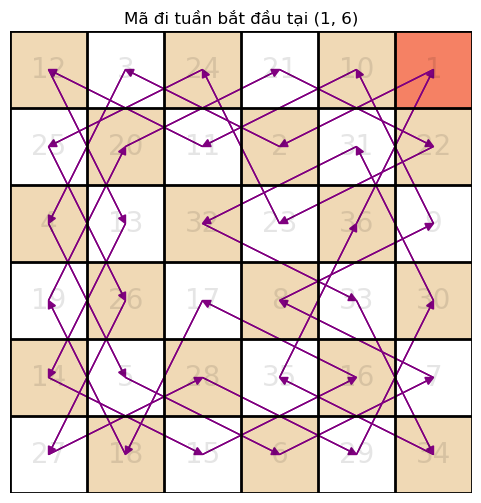

In [175]:
def vebanco(board, x, y):
    if board is None: return None
    else:
        n = len(board)
        plt.figure(figsize=(6,6))
        plt.title(f'Mã đi tuần bắt đầu tại {x,y}')
        plt.xlim(0,n)
        plt.ylim(0,n)
        for i in range(0, n+1): ## vẽ lưới
            plt.plot([0, n], [i, i], linewidth=2, color='black')
            plt.plot([i, i], [0, n], linewidth=2, color='black')
            pass
        for i in range(n): ## tô màu ô cho đẹp
            for j in range(n):
                if (i + j) % 2 == 0:
                    plt.fill([j, j+1, j+1, j],[i, i, i+1, i+1],color="#f0d9b5")
                    pass
                plt.fill([y-1, y, y, y-1],[x-1, x-1, x, x],color="#f58164")
                plt.text(j+0.5, i+0.5,str(board[i][j]),ha='center',va='center',fontsize=20,color='black',alpha = 0.1)
                pass
            pass
        pos = [None]*(n**2+1)
        for i in range(n):
            for j in range(n):
                pos[board[i][j]] = (i,j)

        for k in range(1, n*n): ## vẽ mũi tên đường đi
            x1, y1 = pos[k]
            x2, y2 = pos[k+1]
            plt.arrow(y1+0.5, x1+0.5,(y2 - y1), (x2 - x1),head_width=0.1,head_length=0.1,length_includes_head=True,color = 'purple')
            pass

        r1, c1 = pos[n**2]
        r2, c2 = pos[1]
        plt.arrow(c1+0.5, r1+0.5,(c2 - c1), (r2 - r1),head_width=0.1,head_length=0.1,length_includes_head=True,color = 'purple'        )

        plt.gca().invert_yaxis()
        plt.gca().set_aspect('equal')
        plt.axis("off")
        plt.show()
        pass
    
if result is None: print('Không có lời giải')
elif len(result) > 0:
    b = result[0]
    vebanco(b, x0, y0)
else: print('Không có lời giải')

### Cách 2: Thuật toán Tham lam + heuristic (sử dụng thêm restart+random tie để chắc chắn có lời giải)

```
madituan(n, x0, y0)
    while true:
        reset bàn cờ board
        đặt mã ở (x0,y0)
        x=x0, y=y0
        for i = 1 to n^2:
            nếu ở bước n^2-1:
                kiểm tra các ô tiếp theo, chọn ô có khả năng về lại (x0, y0), nếu không thì dừng lặp (vì không có lời giải)
            ngược lại:
                chọn ngẫu nhiên ô tiếp theo có bậc nhỏ nhất, nếu không có thì dừng lặp (vì đã kín lối đi)
            board[x0][y0] = i
        nếu bước cuối cùng có thể đi tới ô bắt đầu (x0,y0)
            return Solution
```         
*Chỉ có thể tìm được 1 kết quả*

#### Cài đặt tham lam + heuristic

In [176]:
result2 = []
board2 = madituan_heuristic(n = 8 , x0 = 1 , y0 = 8)
if board2 is None:
        print("Không tìm được lời giải")
else:
    result2.append([row[:] for row in board2])
print(result2)

[[[28, 25, 6, 23, 20, 39, 4, 1], [7, 22, 27, 40, 5, 2, 19, 38], [26, 29, 24, 21, 56, 37, 64, 3], [43, 8, 53, 36, 41, 48, 55, 18], [30, 35, 42, 49, 54, 57, 14, 63], [9, 44, 33, 52, 47, 60, 17, 58], [34, 31, 46, 11, 50, 15, 62, 13], [45, 10, 51, 32, 61, 12, 59, 16]]]


#### Kết quả

In [177]:
in_ketqua(result2)

1
28 25  6 23 20 39  4  1 
 7 22 27 40  5  2 19 38 
26 29 24 21 56 37 64  3 
43  8 53 36 41 48 55 18 
30 35 42 49 54 57 14 63 
 9 44 33 52 47 60 17 58 
34 31 46 11 50 15 62 13 
45 10 51 32 61 12 59 16 


#### Biểu diễn hình ảnh

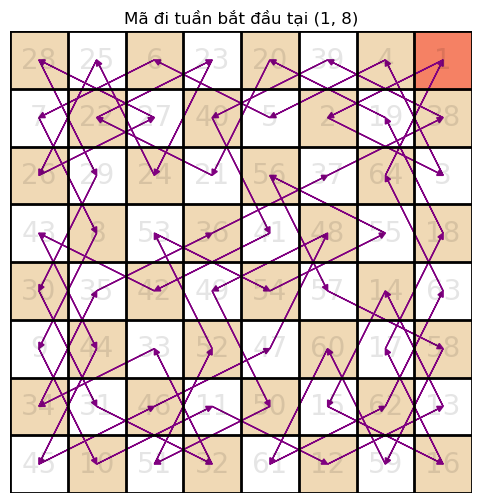

In [178]:
vebanco(board2, 1, 8)

## 4-5. Tô màu đồ thị

*Xem thêm: https://vi.wikipedia.org/wiki/T%C3%B4_m%C3%A0u_%C4%91%E1%BB%93_th%E1%BB%8B*

Cho n thành phố, hãy tô màu các thành phố này sao cho không có bất kỳ hai thành phố nào kề nhau được tô cùng một
màu và số màu được tô là ít nhất có thể.

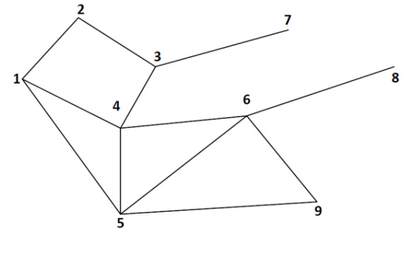

In [179]:
%%writefile tomau.inp
9
1 2
1 4
1 5
2 3
3 4
3 7
4 5
4 6
5 6
5 9
6 8
6 9

Overwriting tomau.inp


### Đọc dữ liệu

In [180]:
from tomau import *
n, adj = readFile(file_path="tomau.inp") ## đưa về ma trận kề
print(n)
in_matran(adj)

Đọc dữ liệu thành công!
9
0 1 0 1 1 0 0 0 0 
1 0 1 0 0 0 0 0 0 
0 1 0 1 0 0 1 0 0 
1 0 1 0 1 1 0 0 0 
1 0 0 1 0 1 0 0 1 
0 0 0 1 1 0 0 1 1 
0 0 1 0 0 0 0 0 0 
0 0 0 0 0 1 0 0 0 
0 0 0 0 1 1 0 0 0 


### Cách 1: Backtracking

```
backtracking(u)
    if với mọi u thuộc G, color[u] != 0
        return SUCCESS
    thử với từng màu c > 0: 
        nếu tô màu cho u hợp lệ: (không trùng màu với các đỉnh kề)
            color[u] = c
            backtracking(u+1) (thử đỉnh tiếp theo)
            color[u] = 0
    return FAILURE
tomaudothi(G):
    backtracking(1)
```

#### Cài đặt

In [181]:
backtracking_result = tomau_backtracking(n, adj)
print(backtracking_result)

[[1, 2, 1, 2, 3, 1, 2, 2, 2]]


#### Kết quả

In [182]:
"""
3           (số màu đã tô là 3)
1 3 6       (màu 1)
2 4 7 8 9   (màu 2)
5           (màu 3)
"""
tomau(backtracking_result)

3
1 3 6 
2 4 7 8 9 
5 


### Cách 2: Thuật toán Tham lam

Chọn đỉnh bậc cao nhấth, tô màu tối ưu nhất
```
tomaudothi(G):
    khởi tạo tập D lưu các đỉnh theo số bậc giảm dần
    Với mỗi đỉnh u thuộc D: (từ bậc cao nhất đến bậc thấp nhất)
        used = rỗng
        Duyệt các đỉnh kề v của u:
            if color[v] != 0: thêm màu đã được tô vào used
        chọn màu tối ưu nhất c không nằm trong used
        color[u] = c
```

#### Tính bậc của một đỉnh

In [183]:
 ##0-based 
"""Tương ứng với đỉnh 5 có bậc là 4"""
print(bac(adj, 4))
"""Tương ứng với đỉnh 4 có bậc là 4"""
print(bac(adj, 3))
"""Tương ứng với đỉnh 1 có bậc là 3"""
print(bac(adj, 0))
"""Tương ứng với đỉnh 9 có bậc là 2"""
print(bac(adj, 8))

4
4
3
2


#### Cài đặt

In [184]:
greedy_result = tomau_greedy(n, adj, debug = False)
print(greedy_result)

[[1, 2, 1, 3, 2, 1, 2, 2, 3]]


#### Kết quả

In [185]:
tomau(greedy_result)

3
1 3 6 
2 5 7 8 
4 9 


### Cách 3: Thuật toán heuristic (Degree of Saturation)

Sử dụng heuristic dựa trên hệ số bão hòa màu (số màu khác nhau của các đỉnh hàng xóm)
```
tomaudothi(G):
    khởi tạo maxheap D lưu các đỉnh theo thứ tự ưu tiên (saturation, degree, vertex)
    với mọi đỉnh ban đầu saturation = 0
    Trong khi D không rỗng:
        u = pop(D)
        nếu color[u] != 0: continue
        used = rỗng
        Duyệt các đỉnh kề v của u:
            if color[v] != 0: thêm màu đã được tô vào used
        chọn màu tối ưu nhất c không nằm trong used
        color[u] = c
        Với các đỉnh kề chưa tô màu v của u:
            tính hệ số saturation của v
            cập nhật lại hệ số s của v trong heap bằng cách push vào D
```

#### Cài đặt

In [186]:
# Sử dụng max heap với tập các phần tử (saturation, degree, vertex)
heu_result = tomau_heuristic(n, adj, debug=True)
print(heu_result)

[(0, -4, 3), (0, -4, 4), (0, -4, 5), (0, -2, 1), (0, -3, 0), (0, -3, 2), (0, -1, 6), (0, -1, 7), (0, -2, 8)]
[(0, -4, 4), (0, -3, 0), (0, -4, 5), (0, -2, 1), (0, -2, 8), (0, -3, 2), (0, -1, 6), (0, -1, 7)]
current_vertice = 3 with s = 0
used_color = set()
coloring 3 by 1
color = [0, 0, 0, 1, 0, 0, 0, 0, 0]

[(0, -4, 4), (0, -3, 0), (0, -4, 5), (0, -3, 0), (0, -3, 2), (0, -4, 5), (0, -1, 6), (0, -1, 7), (0, -2, 1), (0, -2, 8), (0, -3, 2)]
current_vertice = 4 with s = 0
used_color = {1}
coloring 4 by 2
color = [0, 0, 0, 1, 2, 0, 0, 0, 0]

[(0, -4, 5), (0, -3, 0), (0, -4, 5), (0, -3, 0), (0, -3, 2), (0, -3, 0), (0, -2, 8), (0, -1, 7), (0, -2, 1), (0, -2, 8), (0, -3, 2), (0, -1, 6)]
current_vertice = 5 with s = 0
used_color = {1, 2}
coloring 5 by 3
color = [0, 0, 0, 1, 2, 3, 0, 0, 0]

[(0, -3, 0), (0, -3, 0), (0, -2, 8), (0, -2, 1), (0, -3, 2), (0, -2, 8), (0, -1, 7), (0, -1, 7), (0, -1, 6), (0, -2, 8), (0, -3, 2)]
current_vertice = 0 with s = 0
used_color = {1, 2}
coloring 0 by 3
color = 

#### Kết quả

In [187]:
tomau(heu_result)

3
2 4 7 8 9 
3 5 
1 6 


### Ứng dụng vào đồ thị sau:
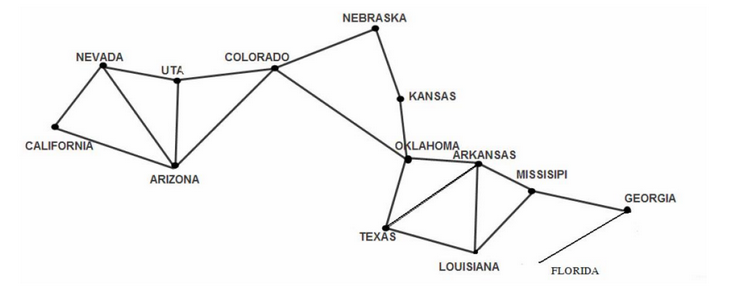

#### Quy ước:


In [188]:
m = 14
vertex_name = { 0:"California",1:"Nevada",2:"UTA",3:"Arizona",4:"Colornado",5:"Nebraska",6:"Kankas",
                7:"Oklahoma",8:"Texas",9:"Arkansas",10:"Louisiana",11:"Missisipi",12:"Georgia",13:"Florida"}
## với California tương ứng với đỉnh 0,...

color_name = [None,"red","blue","yellow","green","orange","purple","pink","brown","black","white",
              "gray","cyan","magenta","lime","indigo","violet","gold","silver","navy","maroon"]
## với color_name[0] là không tô màu

edge = [(0,1),(0,3),(1,2),(1,3),(2,3),(2,4),(3,4),(4,5),(4,7),(5,6),(6,7),(7,8),(7,9),(8,9),(8,10),(9,10),(9,11),(10,11),(11,12),(12,13)]
print(m)

matrix = [[0]*m for _ in range(m)]
for u, v in edge:
        matrix[u][v] = 1
        matrix[v][u] = 1

in_matran(matrix)

14
0 1 0 1 0 0 0 0 0 0 0 0 0 0 
1 0 1 1 0 0 0 0 0 0 0 0 0 0 
0 1 0 1 1 0 0 0 0 0 0 0 0 0 
1 1 1 0 1 0 0 0 0 0 0 0 0 0 
0 0 1 1 0 1 0 1 0 0 0 0 0 0 
0 0 0 0 1 0 1 0 0 0 0 0 0 0 
0 0 0 0 0 1 0 1 0 0 0 0 0 0 
0 0 0 0 1 0 1 0 1 1 0 0 0 0 
0 0 0 0 0 0 0 1 0 1 1 0 0 0 
0 0 0 0 0 0 0 1 1 0 1 1 0 0 
0 0 0 0 0 0 0 0 1 1 0 1 0 0 
0 0 0 0 0 0 0 0 0 1 1 0 1 0 
0 0 0 0 0 0 0 0 0 0 0 1 0 1 
0 0 0 0 0 0 0 0 0 0 0 0 1 0 


#### Biểu diễn đồ thị

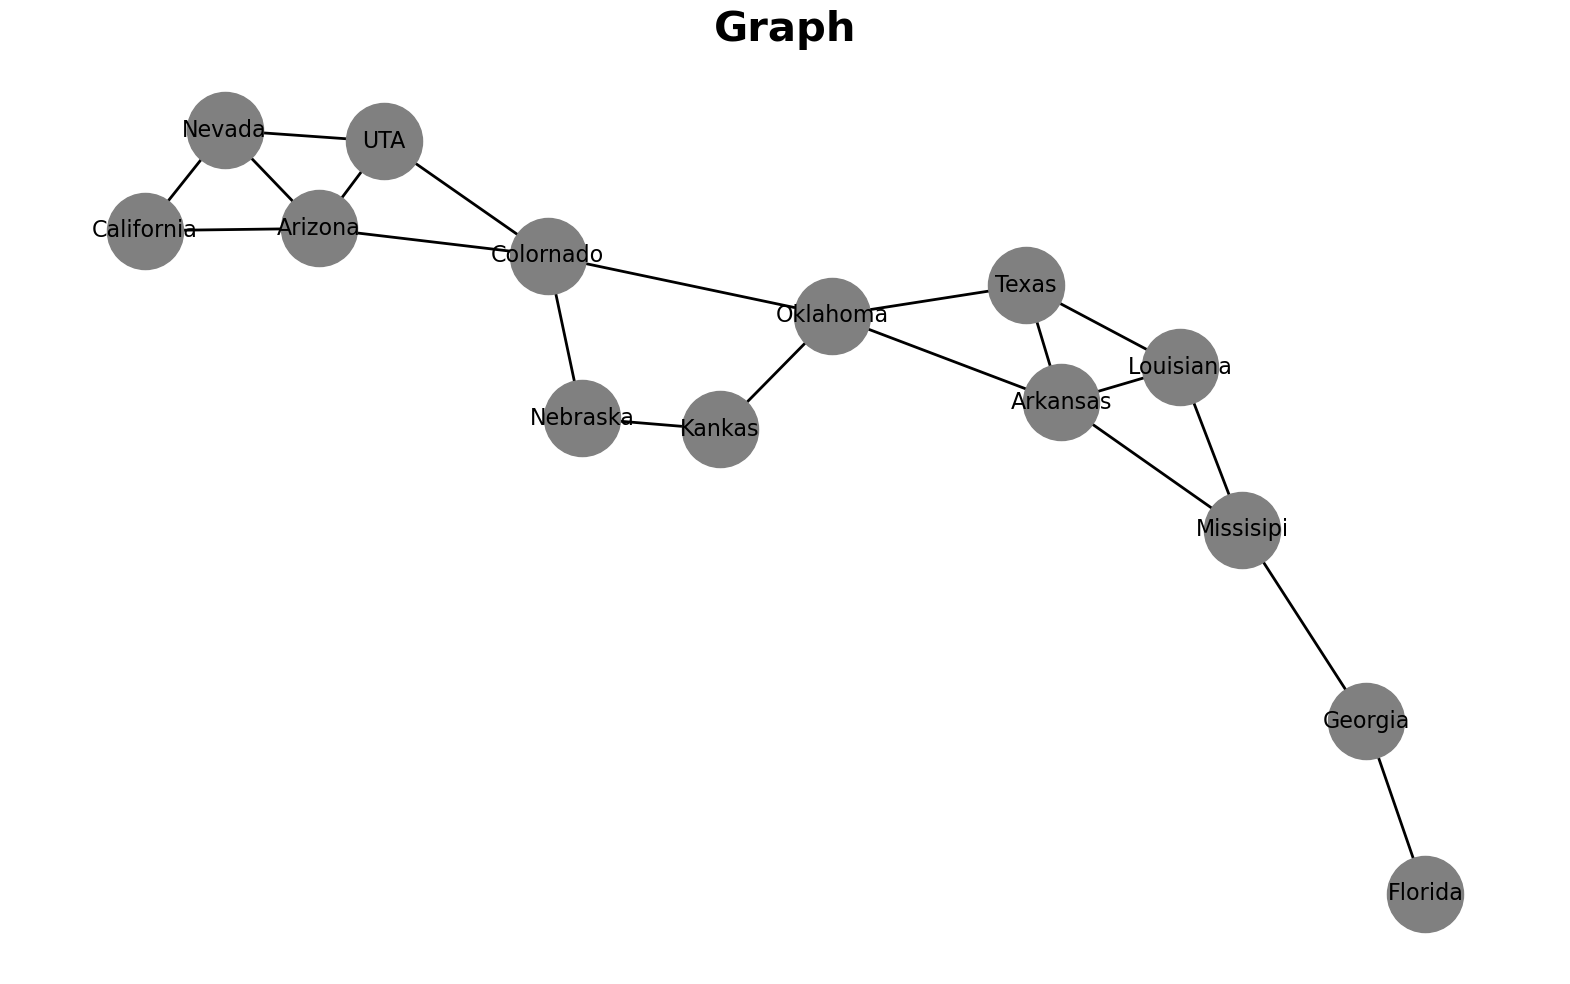

In [189]:
import matplotlib.pyplot as plt
import networkx as nx

def coloring_graph(edge, color=None, labels=None, title=None):
    _, ax = plt.subplots(figsize=(20,12))
    
    g = nx.Graph()
    g.add_edges_from(edge)
    pos = nx.spring_layout(g, seed=50)

    if color is None:
        node_colors = "gray"
    else:
        node_colors = [color_name[color[node]] for node in g.nodes()]

    if labels is None:
        nx.draw(
            g, pos,
            with_labels=True,
            node_size=3000,
            font_size=16,
            width=2,
            node_color=node_colors,
        )
    else:
        nx.draw(
            g, pos,
            with_labels=True,
            labels=labels,
            node_size=3000,
            font_size=16,
            width=2,
            node_color=node_colors,
        )

    if title:
        ax.set_title(title, fontsize=30, fontweight="bold")

    plt.show()



coloring_graph(edge,labels=vertex_name, title="Graph")

#### Áp dụng các thuật toán

In [190]:
result1 = tomau_backtracking(m, matrix)
result2 = tomau_greedy(m, matrix)
result3 = tomau_heuristic(m, matrix)

print(result1, end="\n\n")
print(result2, end="\n\n")
print(result3, end="\n\n")


[[1, 2, 1, 3, 2, 1, 2, 1, 2, 3, 1, 2, 1, 2]]

[[3, 1, 3, 2, 1, 2, 1, 2, 4, 1, 3, 2, 1, 2]]

[[3, 2, 3, 1, 2, 1, 2, 1, 3, 2, 1, 3, 1, 2]]



#### Biểu diễn kết quả

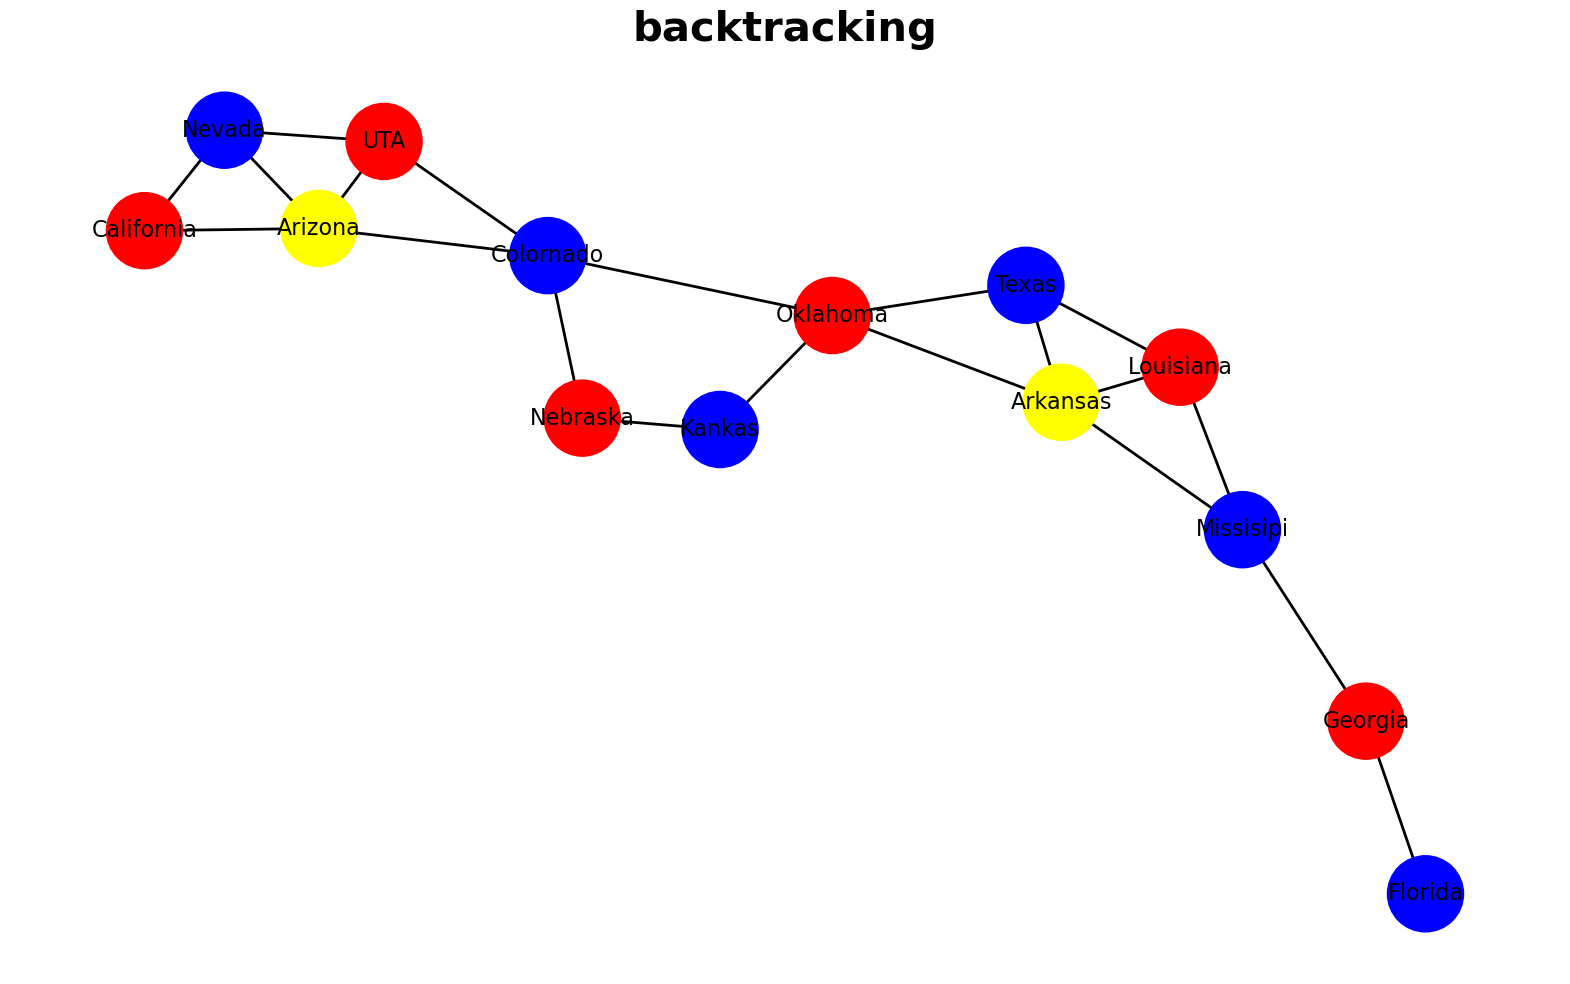

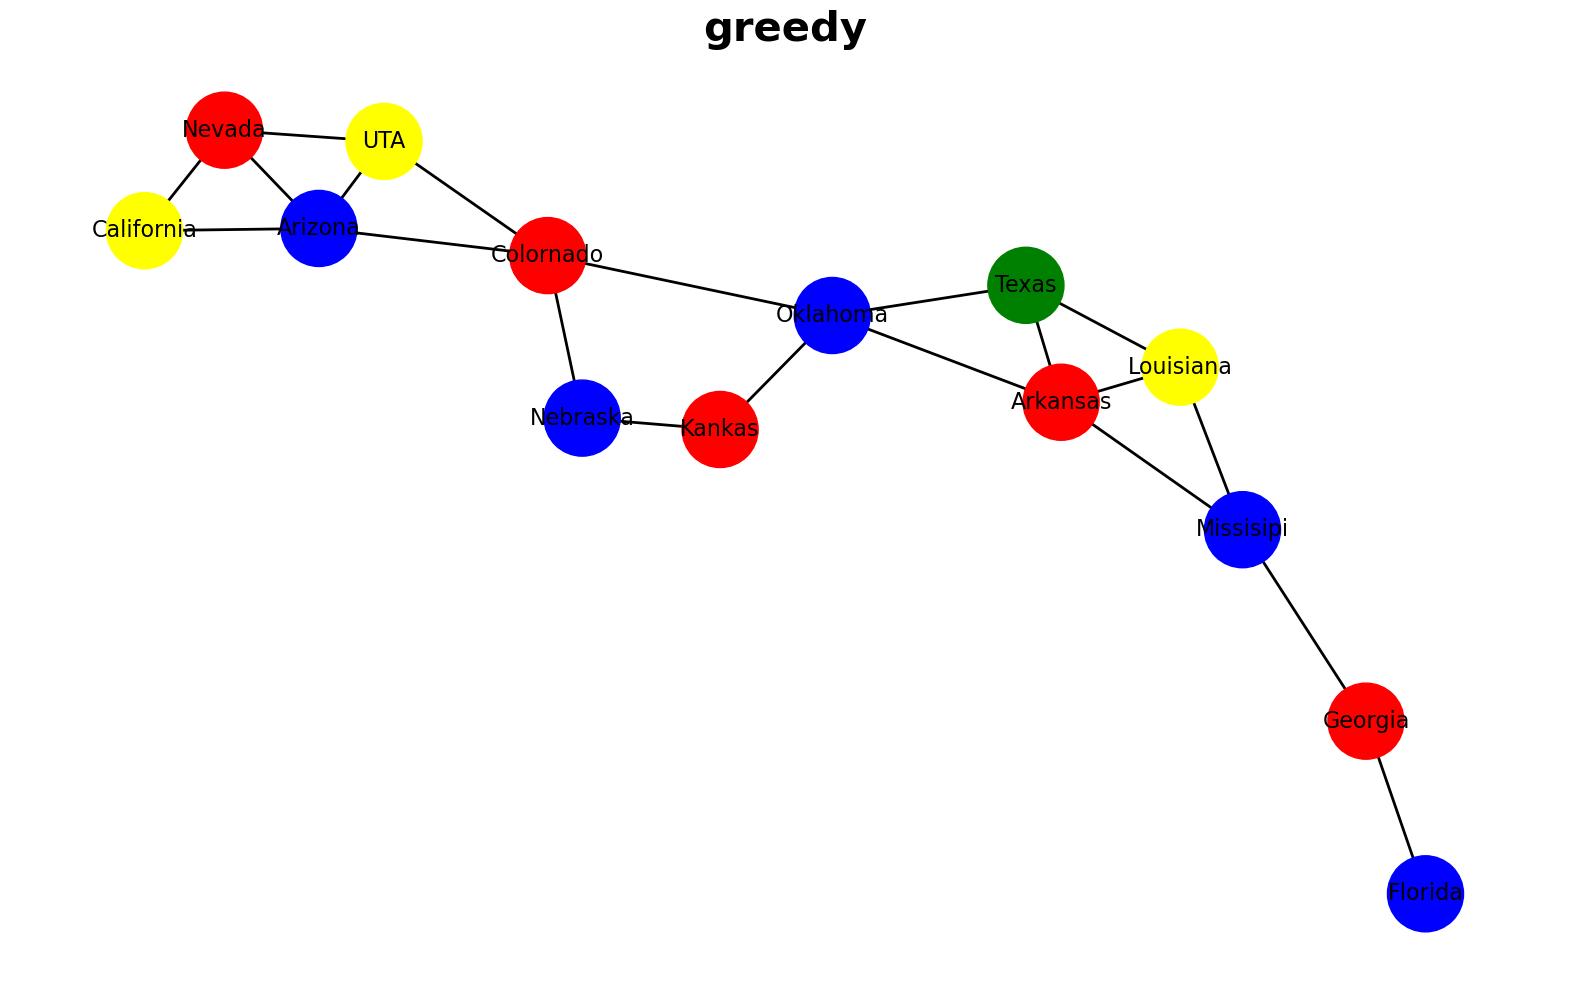

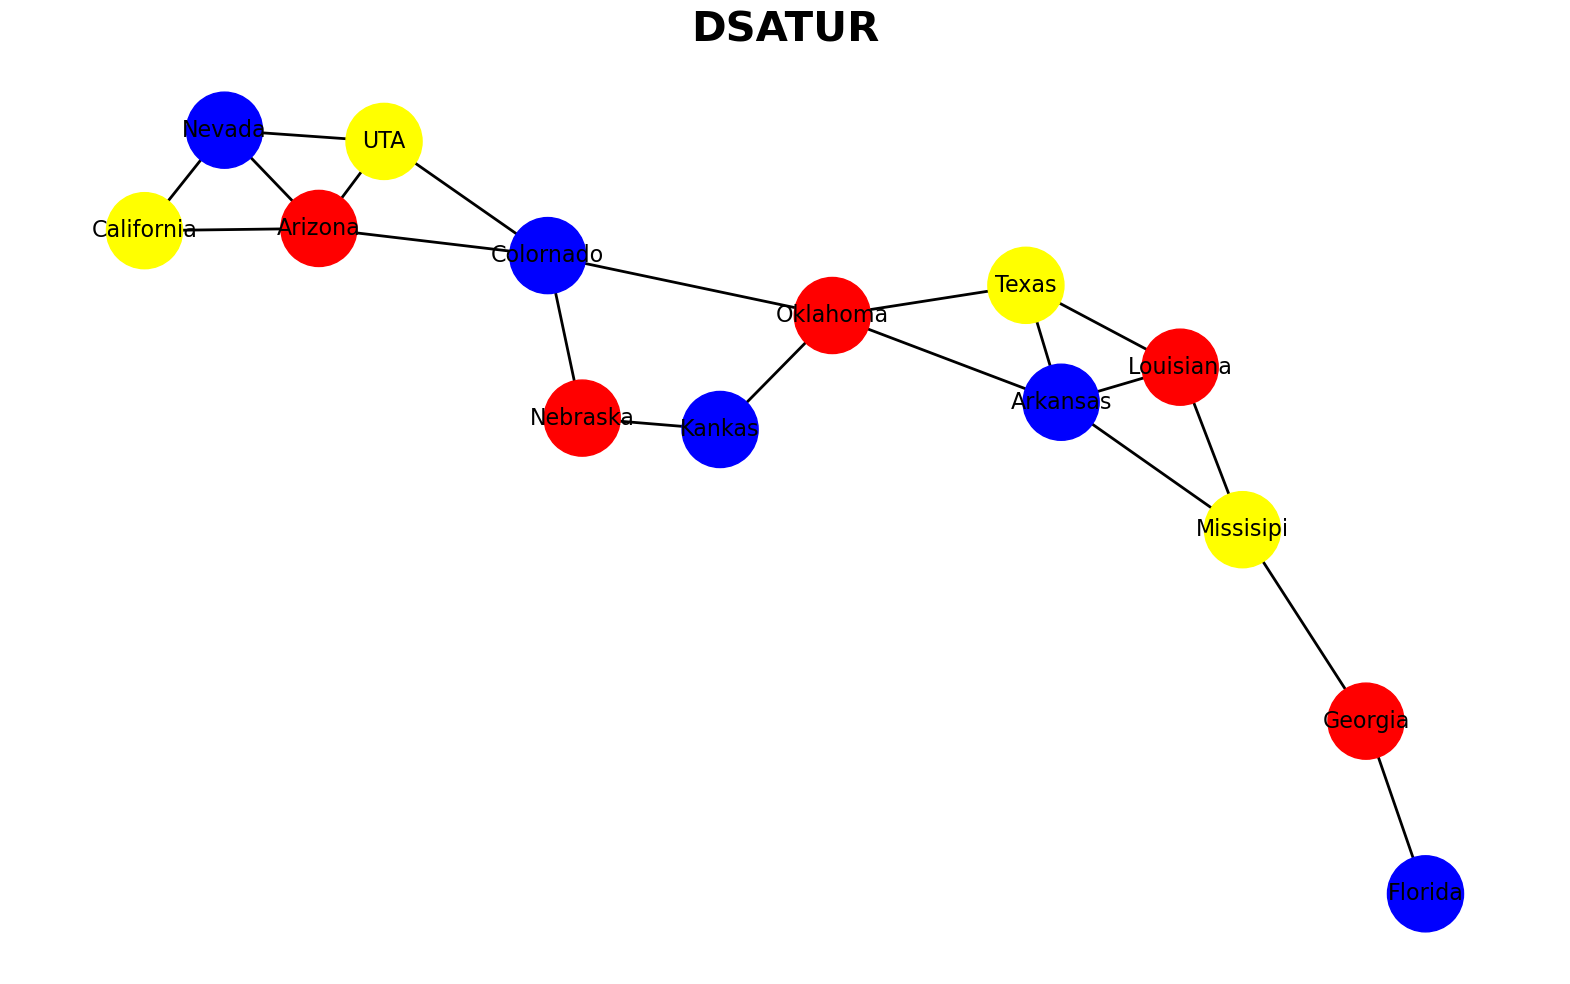

In [191]:
coloring_graph(edge, color = result1[0], labels=vertex_name, title="backtracking")

coloring_graph(edge, color = result2[0], labels=vertex_name, title="greedy")

coloring_graph(edge, color = result3[0], labels=vertex_name, title="DSATUR")



In [192]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Bài tập về nhà:
## 1. Liệt kê hoán vị
```
backtracking(build):
        if độ dài build == n:
            return SUCCESS
        for mỗi phần tử c:
            if chưa dùng c:
                thêm c vào build
                backtracking(build)
                lấy c khỏi build
        return FAILURE
permutation(n)
    build = rỗng
    backtracking(build)
```

In [193]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [194]:
%%writefile hoanvi.inp
3
F
B
A

Overwriting hoanvi.inp


### Đọc dữ liệu

In [195]:
from hoanvi import *
f, comb = readFile("hoanvi.inp")
print(f)
print(comb)

3
['F', 'B', 'A']


### Cài đặt backtracking sinh hoán vị 

In [196]:
res = hoanvi(f, comb)
print(res)
print(len(res))

[['F', 'B', 'A'], ['F', 'A', 'B'], ['B', 'F', 'A'], ['B', 'A', 'F'], ['A', 'F', 'B'], ['A', 'B', 'F']]
6


### Kết quả

In [197]:
in_ketqua(res)

6
F B A 
F A B 
B F A 
B A F 
A F B 
A B F 


## 2. Điền bảng số (Trò chơi Sodoku)

Trò chơi sau đây do Hirofumi Fujiwara đề xuất Trong một lưới ô vuông kích thước 9x9 cần điền các số từ 1 đến 9
sao cho trong mỗi một dòng, mỗi một cột và mỗi một trong số 9 lưới ô vuông con kích thước 3x3 đều có mặt tất cả
các số từ 1 đến 9.

In [198]:
%%writefile fujiwara.inp
.....2.3.
374..6.2.
.....8.1.
258......
.........
......493
.4.1.....
.2.8..675
.6.5.....

Overwriting fujiwara.inp


### Đọc dữ liệu

In [199]:
from fujiwara import *
sodoku  = readFile("fujiwara.inp")
print(sodoku)
sudoku_board(sodoku, hide = False, based0=False)

[[-1, -1, -1, -1, -1, 1, -1, 2, -1], [2, 6, 3, -1, -1, 5, -1, 1, -1], [-1, -1, -1, -1, -1, 7, -1, 0, -1], [1, 4, 7, -1, -1, -1, -1, -1, -1], [-1, -1, -1, -1, -1, -1, -1, -1, -1], [-1, -1, -1, -1, -1, -1, 3, 8, 2], [-1, 3, -1, 0, -1, -1, -1, -1, -1], [-1, 1, -1, 7, -1, -1, 5, 6, 4], [-1, 5, -1, 4, -1, -1, -1, -1, -1]]
0 0 0 0 0 2 0 3 0 
3 7 4 0 0 6 0 2 0 
0 0 0 0 0 8 0 1 0 
2 5 8 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 0 
0 0 0 0 0 0 4 9 3 
0 4 0 1 0 0 0 0 0 
0 2 0 8 0 0 6 7 5 
0 6 0 5 0 0 0 0 0 



### Cài đặt backtracking
```
backtracking(board)
    chọn ô A trên board có ít lựa chọn nhất ở trạng thái hiện tại
    nếu các ô đã điền đủ: return SUCCESS
    Lần lượt thử các số hợp lệ:
        đặt số vào ô A
        backtracking(board)
        gỡ số ở ô A
    return FAILURE

sodoku()
    bảng số đầu vào board
    backtracking(board)
```

#### Cài đặt thành phần bitmask quét và tìm ô có ít lựa chọn nhất

In [200]:
box = [0]*9
row = [0]*9
col = [0]*9

for i in range(9):
    for j in range(9):
        if sodoku[i][j] != -1:
            box[(i//3)*3+j//3] |= (1 << sodoku[i][j]) # |= (1<<k) bật bit thứ k (tính từ 0) ; ^= (1<<K) tắt bit thứ K
            col[j] |= (1 << sodoku[i][j])
            row[i] |= (1 << sodoku[i][j])
            pass
        pass
    pass
best = find_best_start(board=sodoku, box=box, row=row, col=col)
print(best)
i, j, mask = best
nums = []
while mask:
    bit = mask & -mask
    nums.append(bit.bit_length())
    mask ^= bit
    pass

print(f'Tương ứng với ô [dòng {i+1}, cột {j+1}] với {len(nums)} số có thể điền: {nums}')

(1, 3, 256)
Tương ứng với ô [dòng 2, cột 4] với 1 số có thể điền: [9]


#### Backtracking

In [201]:
sresult = solver(sodoku)
print(sresult)
print('0-based')

[[[0, 7, 4, 6, 3, 1, 8, 2, 5], [2, 6, 3, 8, 0, 5, 4, 1, 7], [5, 8, 1, 2, 4, 7, 6, 0, 3], [1, 4, 7, 3, 8, 2, 0, 5, 6], [3, 2, 8, 5, 6, 0, 7, 4, 1], [6, 0, 5, 1, 7, 4, 3, 8, 2], [4, 3, 2, 0, 5, 6, 1, 7, 8], [8, 1, 0, 7, 2, 3, 5, 6, 4], [7, 5, 6, 4, 1, 8, 2, 3, 0]]]
0-based


#### Kết quả

In [202]:
if len(sresult) == 0 or sresult is None:
    print(0)
else:
    print(1)
    s = sresult[0]
    sudoku_board(s, hide = False, based0=False)

1
1 8 5 7 4 2 9 3 6 
3 7 4 9 1 6 5 2 8 
6 9 2 3 5 8 7 1 4 
2 5 8 4 9 3 1 6 7 
4 3 9 6 7 1 8 5 2 
7 1 6 2 8 5 4 9 3 
5 4 3 1 6 7 2 8 9 
9 2 1 8 3 4 6 7 5 
8 6 7 5 2 9 3 4 1 



# Kết thúc